In [77]:
import pyexasol
import configparser
import pandas as pd
from haversine import haversine, Unit

pd.set_option('max_columns', None)

In [23]:
def conn(config_filepath, schema, env):
    """Exasol connection"""
    env=env.upper()
    config = configparser.ConfigParser()
    file = config_filepath+schema+env+'.ini'
    config.read(file)
    key=schema.lower()+env
    return pyexasol.connect(dsn=config[key]['dsn'], user=config[key]['user'], password=config[key]['pwd'], schema=config[key]['schema'])

In [24]:
config_filepath='C:/Users/svi02/.spyder-py3/'
env='prod'
schema='pfx'
connect=conn(config_filepath,schema, env)
df = connect.export_to_pandas("SELECT * FROM DWHPFX.ERFP_POI_CLUSTER WHERE UPPER(RFP_PHASE) LIKE 'FINAL_BID_ANALYSIS'  AND RFP_ID='0618cb8b-6aab-4cc7-838a-815ccc7a7c6e'")
df.head()

,RFP_PROCESS_ID,RFP_PHASE,RFP_ID,RFP_NAME,RFP_DESTINATION_ID,RFP_DESTINATION_NAME,RFP_POI_ID,RFP_POI_NAME,RFP_POI_LATITUDE,RFP_POI_LONGITUDE,RFP_HOTEL_ID,RFP_HOTEL_NAME,RFP_HOTEL_LATITUDE,RFP_HOTEL_LONGITUDE,OPTIMAL_PORTFOLIO_SIZE
0,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,393cde24-35d4-4300-b275-dc79efee9671,Kulim,393cde24-35d4-4300-b275-dc79efee921,vPOI_Kulim_2,5.413190,100.329857,775453,The Wembley - A St Giles Hotel,5.413190,100.329857,NaN
1,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,247d4bfa-0781-4261-8625-6fecdaecbb6e,Budapest - CCR,247d4bfa-0781-4261-8625-6fecdaecb1e,vPOI_Budapest - CCR_1,47.506500,19.058800,424649,Star Inn Hotel Budapest Centrum,47.506500,19.058800,NaN
2,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,6083ba32-a532-49a9-a4ae-a3660b04bc0c,Turin - CCR,6083ba32-a532-49a9-a4ae-a3660b04b2c,vPOI_Turin - CCR_2,45.076234,7.667027,410004,Class Residence,45.076234,7.667027,NaN
3,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,9a6b67de-79b0-49df-bf60-4d9c778e380c,Landau an der Isar - Rottersdorf,ed4070bc-753e-43da-975b-70c9ba1231ec,Landau 1,48.685930,12.694510,931528,motel isar,48.692020,12.670953,NaN
4,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,30ba6ce1-7697-4b20-8d00-aaecc9fbd3b6,Sousse,30ba6ce1-7697-4b20-8d00-aaecc9fbd16,vPOI_Sousse_1,35.842414,10.627048,475497,Movenpick Resort & Marine Spa Sousse,35.842414,10.627048,NaN


In [64]:
lat_long = ['RFP_POI_LATITUDE','RFP_POI_LONGITUDE','RFP_HOTEL_LATITUDE', 'RFP_HOTEL_LONGITUDE']
for item in lat_long:
    df[item] = df[item].astype('float64')

df['DISTANCE_KMS'] = df.apply(lambda row: haversine((row['RFP_POI_LATITUDE'],row['RFP_POI_LONGITUDE']), \
                                        (row['RFP_HOTEL_LATITUDE'],row['RFP_HOTEL_LONGITUDE'])
                                       ),axis=1
                              )
df.head()                              

,RFP_PROCESS_ID,RFP_PHASE,RFP_ID,RFP_NAME,RFP_DESTINATION_ID,RFP_DESTINATION_NAME,RFP_POI_ID,RFP_POI_NAME,RFP_POI_LATITUDE,RFP_POI_LONGITUDE,RFP_HOTEL_ID,RFP_HOTEL_NAME,RFP_HOTEL_LATITUDE,RFP_HOTEL_LONGITUDE,OPTIMAL_PORTFOLIO_SIZE,DISTANCE_KMS
0,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,393cde24-35d4-4300-b275-dc79efee9671,Kulim,393cde24-35d4-4300-b275-dc79efee921,vPOI_Kulim_2,5.413190,100.329857,775453,The Wembley - A St Giles Hotel,5.413190,100.329857,NaN,0.00000
1,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,247d4bfa-0781-4261-8625-6fecdaecbb6e,Budapest - CCR,247d4bfa-0781-4261-8625-6fecdaecb1e,vPOI_Budapest - CCR_1,47.506500,19.058800,424649,Star Inn Hotel Budapest Centrum,47.506500,19.058800,NaN,0.00000
2,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,6083ba32-a532-49a9-a4ae-a3660b04bc0c,Turin - CCR,6083ba32-a532-49a9-a4ae-a3660b04b2c,vPOI_Turin - CCR_2,45.076234,7.667027,410004,Class Residence,45.076234,7.667027,NaN,0.00000
3,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,9a6b67de-79b0-49df-bf60-4d9c778e380c,Landau an der Isar - Rottersdorf,ed4070bc-753e-43da-975b-70c9ba1231ec,Landau 1,48.685930,12.694510,931528,motel isar,48.692020,12.670953,NaN,1.85707
4,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,30ba6ce1-7697-4b20-8d00-aaecc9fbd3b6,Sousse,30ba6ce1-7697-4b20-8d00-aaecc9fbd16,vPOI_Sousse_1,35.842414,10.627048,475497,Movenpick Resort & Marine Spa Sousse,35.842414,10.627048,NaN,0.00000


In [101]:
# tmp =[]
# df1=df.iloc[:,:-1]
# ## iterrows approach
# for i, row in df1.iterrows():
# #     print(i, row['RFP_POI_LATITUDE'])
#     hs=haversine((row['RFP_POI_LATITUDE'],row['RFP_POI_LONGITUDE']),(row['RFP_HOTEL_LATITUDE'],row['RFP_HOTEL_LONGITUDE']))
#     tmp.append(hs)

# df1['DISTANCE_KM']= tmp
# df1.head(10)

In [83]:
df1.columns

Index(['RFP_PROCESS_ID', 'RFP_PHASE', 'RFP_ID', 'RFP_NAME',
       'RFP_DESTINATION_ID', 'RFP_DESTINATION_NAME', 'RFP_POI_ID',
       'RFP_POI_NAME', 'RFP_POI_LATITUDE', 'RFP_POI_LONGITUDE', 'RFP_HOTEL_ID',
       'RFP_HOTEL_NAME', 'RFP_HOTEL_LATITUDE', 'RFP_HOTEL_LONGITUDE',
       'OPTIMAL_PORTFOLIO_SIZE', 'DISTANCE_KM'],
      dtype='object')

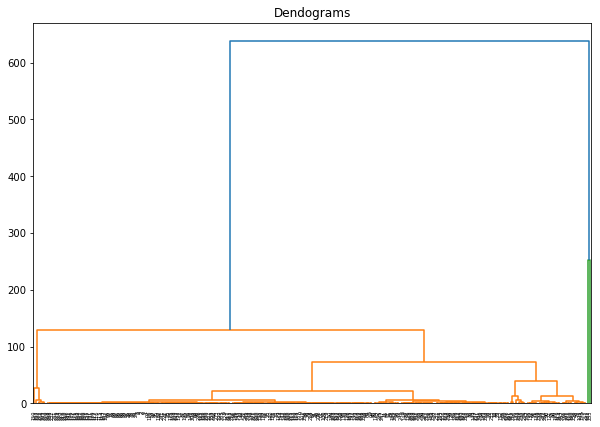

In [87]:
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 7))
plt.title("Dendograms")
dend = shc.dendrogram(shc.linkage(df1[['DISTANCE_KM']], method='ward'))

In [91]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
df1['CLUSTERS']=cluster.fit_predict(df1[['DISTANCE_KM']])

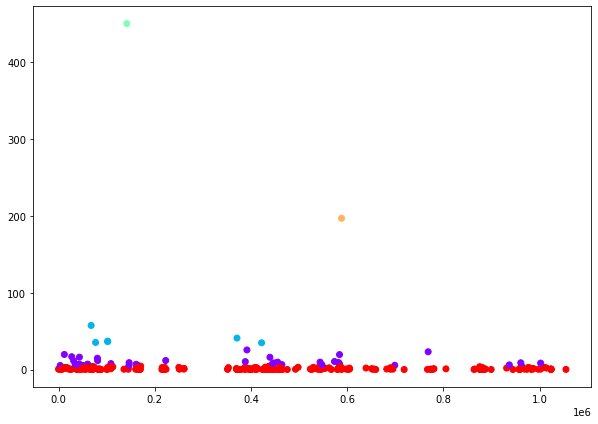

In [100]:
plt.figure(figsize=(10, 7))
plt.scatter(df1['RFP_HOTEL_ID'], df1['DISTANCE_KM'], c=cluster.labels_, cmap='rainbow')

In [93]:
df1.head()

,RFP_PROCESS_ID,RFP_PHASE,RFP_ID,RFP_NAME,RFP_DESTINATION_ID,RFP_DESTINATION_NAME,RFP_POI_ID,RFP_POI_NAME,RFP_POI_LATITUDE,RFP_POI_LONGITUDE,RFP_HOTEL_ID,RFP_HOTEL_NAME,RFP_HOTEL_LATITUDE,RFP_HOTEL_LONGITUDE,OPTIMAL_PORTFOLIO_SIZE,DISTANCE_KM,CLUSTERS
0,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,393cde24-35d4-4300-b275-dc79efee9671,Kulim,393cde24-35d4-4300-b275-dc79efee921,vPOI_Kulim_2,5.413190,100.329857,775453,The Wembley - A St Giles Hotel,5.413190,100.329857,NaN,0.00000,4
1,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,247d4bfa-0781-4261-8625-6fecdaecbb6e,Budapest - CCR,247d4bfa-0781-4261-8625-6fecdaecb1e,vPOI_Budapest - CCR_1,47.506500,19.058800,424649,Star Inn Hotel Budapest Centrum,47.506500,19.058800,NaN,0.00000,4
2,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,6083ba32-a532-49a9-a4ae-a3660b04bc0c,Turin - CCR,6083ba32-a532-49a9-a4ae-a3660b04b2c,vPOI_Turin - CCR_2,45.076234,7.667027,410004,Class Residence,45.076234,7.667027,NaN,0.00000,4
3,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,9a6b67de-79b0-49df-bf60-4d9c778e380c,Landau an der Isar - Rottersdorf,ed4070bc-753e-43da-975b-70c9ba1231ec,Landau 1,48.685930,12.694510,931528,motel isar,48.692020,12.670953,NaN,1.85707,4
4,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,30ba6ce1-7697-4b20-8d00-aaecc9fbd3b6,Sousse,30ba6ce1-7697-4b20-8d00-aaecc9fbd16,vPOI_Sousse_1,35.842414,10.627048,475497,Movenpick Resort & Marine Spa Sousse,35.842414,10.627048,NaN,0.00000,4


In [99]:
cluster.labels_

array([4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 0,
       4, 4, 4, 4, 0, 0, 4, 0, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 1, 0, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 1, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4,
       4, 4, 4, 0, 4, 4, 4, 4, 4, 1, 4, 0, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 0, 2, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 0, 4, 4,
       4, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 3, 4, 4, 0, 0, 4, 0, 4, 4, 4, 4,
       0, 4, 4, 4, 4, 4, 4, 0, 1, 1], dtype=int64)

In [104]:
df1[['CLUSTERS','DISTANCE_KM']].groupby('CLUSTERS').mean()

,DISTANCE_KM
CLUSTERS,
0,10.037321
1,40.220506
2,449.994794
3,196.697330
4,1.019603


In [105]:
df1[df1['CLUSTERS']==2]

,RFP_PROCESS_ID,RFP_PHASE,RFP_ID,RFP_NAME,RFP_DESTINATION_ID,RFP_DESTINATION_NAME,RFP_POI_ID,RFP_POI_NAME,RFP_POI_LATITUDE,RFP_POI_LONGITUDE,RFP_HOTEL_ID,RFP_HOTEL_NAME,RFP_HOTEL_LATITUDE,RFP_HOTEL_LONGITUDE,OPTIMAL_PORTFOLIO_SIZE,DISTANCE_KM,CLUSTERS
182,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,b97cd9ff-ff32-4786-a04b-abd1e0ab91d5,"Greenville, SC",b97cd9ff-ff32-4786-a04b-abd1e0ab915,"vPOI_Greenville, SC_1",34.861915,-82.253776,141805,"Red Roof Inn Greenville, NC",35.581269,-77.378298,NaN,449.994794,2


In [106]:
df1[df1['CLUSTERS']==3]

,RFP_PROCESS_ID,RFP_PHASE,RFP_ID,RFP_NAME,RFP_DESTINATION_ID,RFP_DESTINATION_NAME,RFP_POI_ID,RFP_POI_NAME,RFP_POI_LATITUDE,RFP_POI_LONGITUDE,RFP_HOTEL_ID,RFP_HOTEL_NAME,RFP_HOTEL_LATITUDE,RFP_HOTEL_LONGITUDE,OPTIMAL_PORTFOLIO_SIZE,DISTANCE_KM,CLUSTERS
253,4688f800-b6bd-4bc9-850c-9180eba523b2,FINAL_BID_ANALYSIS,0618cb8b-6aab-4cc7-838a-815ccc7a7c6e,Draexlmaier RFP 2021,e1704fb3-adee-430c-83fe-f24cd6820295,Ingolstadt,e1704fb3-adee-430c-83fe-f24cd682015,vPOI_Ingolstadt_1,48.782908,11.377728,588224,Hotel Adler,48.551165,8.722219,NaN,196.69733,3


In [107]:
df1[['CLUSTERS','RFP_HOTEL_ID']].groupby('CLUSTERS').count()

,RFP_HOTEL_ID
CLUSTERS,
0,38
1,6
2,1
3,1
4,228
